In [52]:
from google.colab import drive
import os

from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from tabulate import tabulate

import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.utils import load_img, img_to_array


In [4]:
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
BATCH_SIZE = 10
EPOCHS = 17

In [6]:
def count_total_images(directory):
    total_images = 0
    for root, _, files in os.walk(directory):
        total_images += len([f for f in files if f.lower().endswith(('jpg', 'jpeg', 'png', 'bmp', 'gif'))])
    return total_images

In [7]:
fruits_and_veggies_train = "/content/drive/My Drive/DL_Dataset/Train"
fruits_and_veggies_test = "/content/drive/My Drive/DL_Dataset/Test"
dataset_path = "/content/drive/My Drive/DL_Dataset"

train_count = count_total_images(fruits_and_veggies_train)
test_count = count_total_images(fruits_and_veggies_test)
total_images = count_total_images(dataset_path)

print(f"Training set contains {train_count} images")
print(f"Test set contains {test_count} images")
print(f"Total number of images in the dataset: {total_images}")

Training set contains 23629 images
Test set contains 6738 images
Total number of images in the dataset: 30367


In [8]:
classifications = ['freshapples',  'rottenapples'] #sorted(os.listdir(fruits_and_veggies_train))
print( len(classifications), classifications)

2 ['freshapples', 'rottenapples']


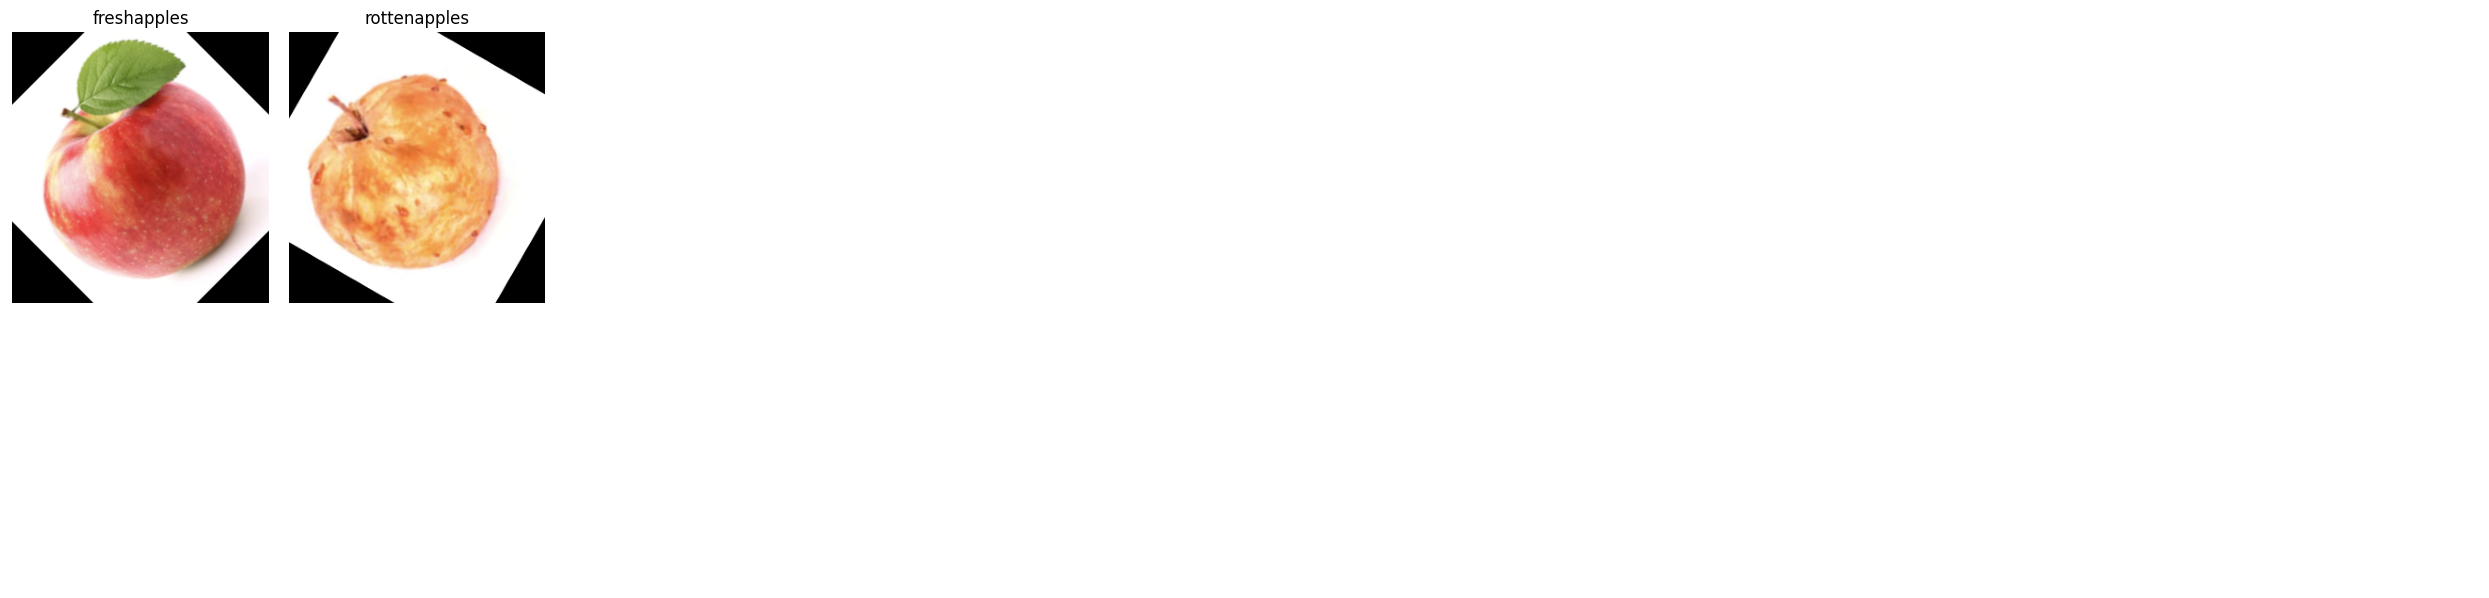

In [9]:
num_classes = len(classifications)
rows, cols = 2, 9  # 2x9 grid
fig, axes = plt.subplots(rows, cols, figsize=(25, 6))

# Flatten axes for easy iteration
axes = axes.flatten()

# Plot one exemplar from each class
for i, class_name in enumerate(classifications):
    class_path = os.path.join(fruits_and_veggies_train, class_name)
    image_files = [f for f in os.listdir(class_path) if f.endswith(('.png', '.jpg', '.jpeg'))]

    if image_files:  # Ensure the class folder is not empty
        img_path = os.path.join(class_path, image_files[0])  # Select first image
        img = Image.open(img_path)
        axes[i].imshow(img)
        axes[i].axis("off")
        axes[i].set_title(class_name)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [10]:
Train_batches = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.vgg16.preprocess_input,
    rescale=1/255.,
    horizontal_flip=True,
    vertical_flip=True
).flow_from_directory(
    directory=fruits_and_veggies_train,
    target_size=(20, 20),
    classes=classifications,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='rgb'
)
Test_batches = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.vgg16.preprocess_input,
    rescale=1/255.
).flow_from_directory(
    directory=fruits_and_veggies_test,
    target_size=(20, 20),
    classes=classifications,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False
)

Found 5672 images belonging to 2 classes.
Found 1779 images belonging to 2 classes.


In [11]:
# Report after splitting
data = [
    ["Training Set", len(Train_batches.filenames)],
    ["Test Set", len(Test_batches.filenames)]
]

report = tabulate(data, headers=["Dataset", "Number of Images"], tablefmt="grid")
print(report)

+--------------+--------------------+
| Dataset      |   Number of Images |
+==============+====================+
| Training Set |               5672 |
+--------------+--------------------+
| Test Set     |               1779 |
+--------------+--------------------+


In [12]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(20, 20, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    # Uncomment the following lines if you want an additional Conv layer
    # Conv2D(128, (3, 3), activation='relu'),
    # MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dense(len(classifications), activation='softmax')  # Ensure 'classifications' is defined
])

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 18, 18, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 9, 9, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,018 (429.76 KB)

 Trainable params: 110,018 (429.76 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(Train_batches, epochs=EPOCHS, validation_data=Test_batches,  verbose=2)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/17
568/568 - 1896s - 3s/step - accuracy: 0.8845 - loss: 0.2698 - val_accuracy: 0.9359 - val_loss: 0.1514
Epoch 2/17
568/568 - 43s - 76ms/step - accuracy: 0.9374 - loss: 0.1546 - val_accuracy: 0.9438 - val_loss: 0.1281
Epoch 3/17
568/568 - 37s - 66ms/step - accuracy: 0.9452 - loss: 0.1313 - val_accuracy: 0.9595 - val_loss: 0.0969
Epoch 4/17
568/568 - 37s - 66ms/step - accuracy: 0.9529 - loss: 0.1189 - val_accuracy: 0.9646 - val_loss: 0.0954
Epoch 5/17
568/568 - 38s - 67ms/step - accuracy: 0.9589 - loss: 0.0999 - val_accuracy: 0.9438 - val_loss: 0.1326
Epoch 6/17
568/568 - 41s - 72ms/step - accuracy: 0.9748 - loss: 0.0775 - val_accuracy: 0.9573 - val_loss: 0.1054
Epoch 7/17
568/568 - 37s - 65ms/step - accuracy: 0.9718 - loss: 0.0716 - val_accuracy: 0.9719 - val_loss: 0.0781
Epoch 8/17
568/568 - 37s - 65ms/step - accuracy: 0.9778 - loss: 0.0634 - val_accuracy: 0.9758 - val_loss: 0.0666
Epoch 9/17
568/568 - 41s - 72ms/step - accuracy: 0.9801 - loss: 0.0487 - val_accuracy: 0.9831 - 

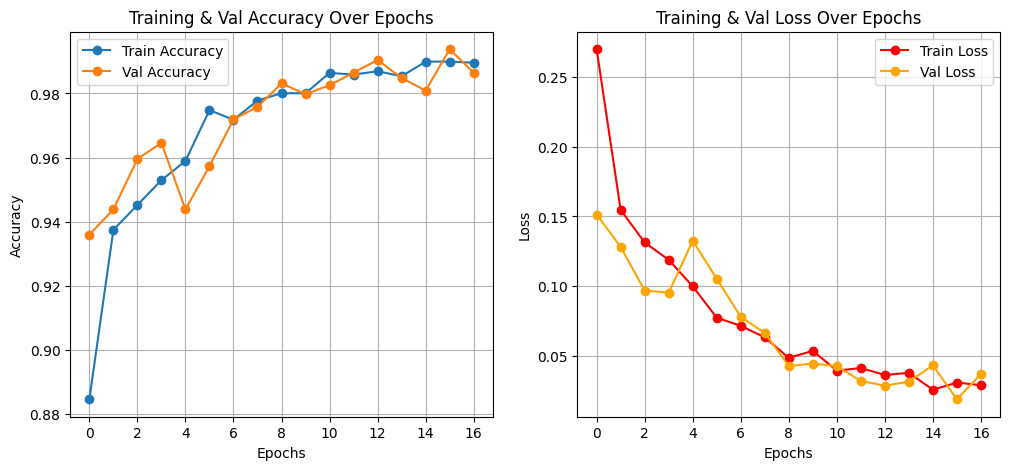

In [14]:
# Plot training & test accuracy and loss
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training & Val Accuracy Over Epochs')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o', color='red')
plt.plot(history.history['val_loss'], label='Val Loss', marker='o', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training & Val Loss Over Epochs')
plt.legend()
plt.grid(True)

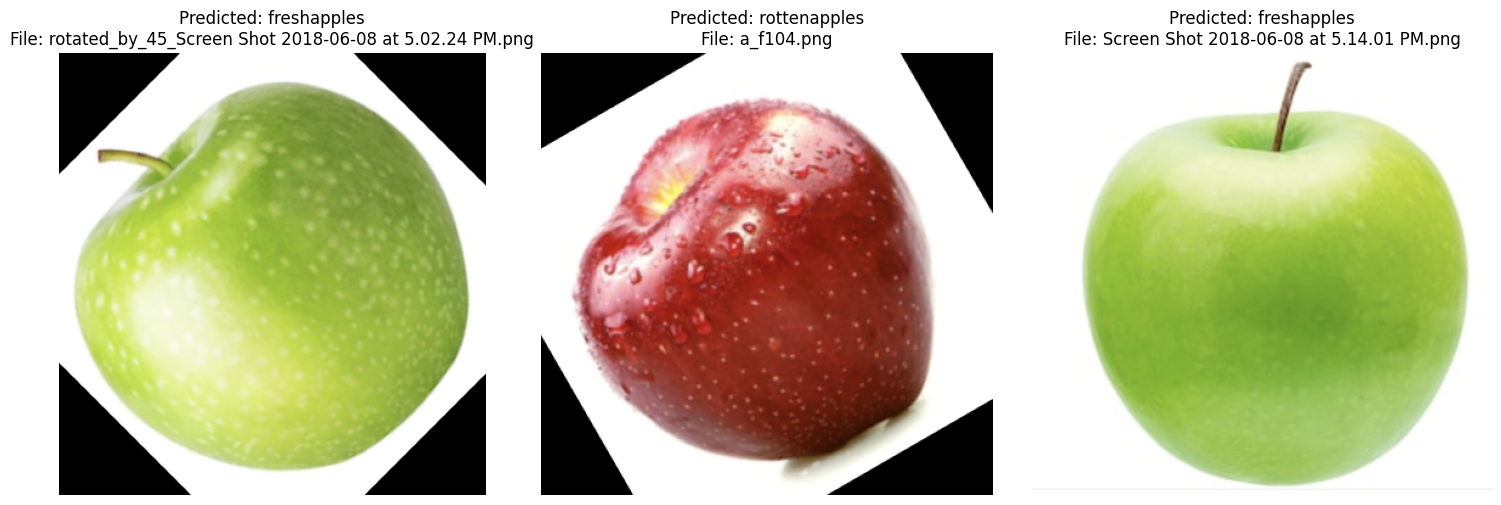

In [70]:
import random

# Pick 3 random image paths
random_paths = random.sample(Test_batches.filepaths, 3)

# Create a horizontal subplot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, path in enumerate(random_paths):
    # Load image and preprocess
    img = load_img(path, target_size=(20, 20))
    img_array = img_to_array(img) / 255.0  # Normalize
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

    # Predict
    pred = model.predict(img_array, verbose=0)
    pred_class = classifications[np.argmax(pred)]

    # Display on corresponding subplot
    axes[i].imshow(load_img(path))
    axes[i].set_title(f"Predicted: {pred_class}\nFile: {path.split('/')[-1]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()